In [ ]:
!pip install opencv-python ipywidgets

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import ipywidgets as widgets
from IPython.display import display

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.8 MB/s eta 0:00:00


Saving photo-1775563623211-4ecef6718f1f.avif to photo-1775563623211-4ecef6718f1f.avif


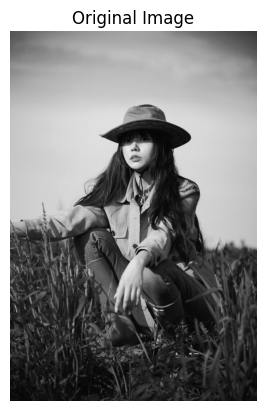

In [ ]:
# ==========================
# UPLOAD IMAGE AND CONVERT TO GRAYSCALE
# ==========================
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

In [ ]:
# ==========================
# SOBEL EDGE DETECTION
# ==========================
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)

In [ ]:
# ==========================
# PREWITT EDGE DETECTION
# ==========================
kernelx = np.array([[-1,0,1],
                    [-1,0,1],
                    [-1,0,1]])

kernely = np.array([[-1,-1,-1],
                    [0,0,0],
                    [1,1,1]])

prewittx = cv2.filter2D(gray, -1, kernelx)
prewitty = cv2.filter2D(gray, -1, kernely)

prewitt = cv2.magnitude(np.float32(prewittx), np.float32(prewitty))

In [ ]:
# ==========================
# CANNY EDGE DETECTION
# ==========================
canny = cv2.Canny(gray, 100, 200)

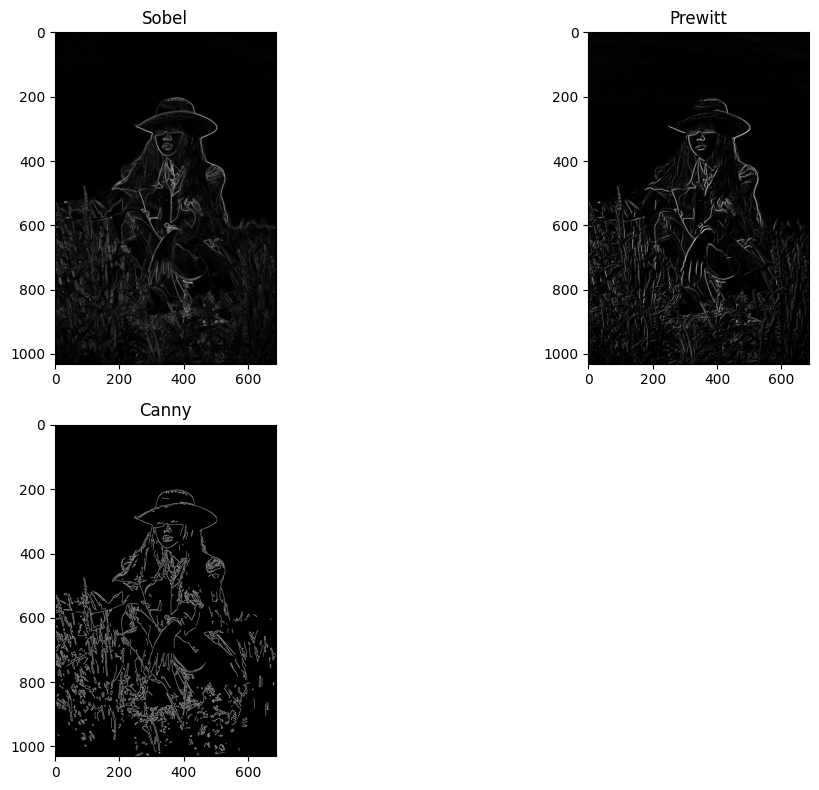

In [ ]:
# ==========================
# DISPLAY EDGE DETECTION RESULTS
# ==========================
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(sobel, cmap='gray')
plt.title("Sobel")

plt.subplot(2,2,2)
plt.imshow(prewitt, cmap='gray')
plt.title("Prewitt")

plt.subplot(2,2,3)
plt.imshow(canny, cmap='gray')
plt.title("Canny")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================
# GLOBAL THRESHOLD (INTERACTIVE)
# ==========================
def global_threshold(T):
    _, thresh = cv2.threshold(gray, T, 255, cv2.THRESH_BINARY)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(gray, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(thresh, cmap='gray')
    plt.title(f"Threshold={T}")
    plt.axis('off')

    plt.show()


widgets.interact(
    global_threshold,
    T=widgets.IntSlider(min=0, max=255, step=5, value=127)
)

interactive(children=(IntSlider(value=127, description='T', max=255, step=5), Output()), _dom_classes=('widget…

<function __main__.global_threshold(T)>

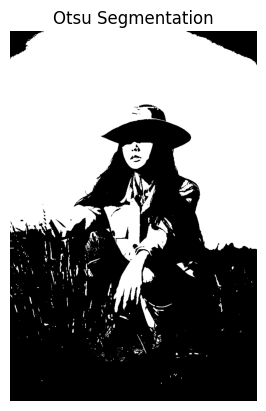

In [ ]:
# ==========================
# OTSU THRESHOLDING
# ==========================
_, otsu = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.imshow(otsu, cmap='gray')
plt.title("Otsu Segmentation")
plt.axis('off')
plt.show()

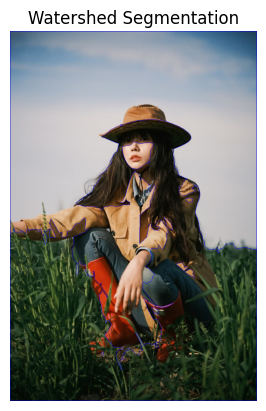

In [ ]:
# ==========================
# WATERSHED SEGMENTATION
# ==========================
img_copy = image.copy()

gray_ws = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)

_, thresh_ws = cv2.threshold(
    gray_ws,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

kernel = np.ones((3,3), np.uint8)

opening = cv2.morphologyEx(
    thresh_ws,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

_, sure_fg = cv2.threshold(
    dist_transform,
    0.7 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1

markers[unknown == 255] = 0

markers = cv2.watershed(img_copy, markers)

img_copy[markers == -1] = [255, 0, 0]


plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation")
plt.axis('off')
plt.show()